# Imports

In [44]:
#Chenk enviroment
import sys
print(sys.executable)

c:\Users\laura.maestro\repos\ds_l7\.venv\Scripts\python.exe


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Initial exploration & data checks


## Load data

In [ ]:
# Path is relative to Notebooks/. Archived exploration; see README for the module equivalents.
df = pd.read_csv(
    "../corona_tested_individuals_ver_006.english.csv",
    dtype={"age_60_and_above": str},
)
df.shape


(278848, 10)

In [47]:
"../data/corona_tested_individuals_ver_006.english.csv"
(278848, 10)
"../data/corona_tested_individuals_ver_0083.english.csv"
(2742596, 10)

(2742596, 10)

In [48]:
df.sample(20)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
56056,2020-04-22,1.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
90258,2020-04-19,0.0,1.0,0.0,0.0,0.0,negative,NaN,female,Abroad
103065,2020-04-17,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
239731,2020-03-27,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other
186963,2020-04-03,0.0,0.0,0.0,0.0,0.0,negative,Yes,female,Other
105866,2020-04-17,0.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other
132629,2020-04-13,0.0,0.0,0.0,0.0,0.0,positive,No,female,Contact with confirmed
240588,2020-03-27,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other
234047,2020-03-28,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other
171806,2020-04-06,0.0,0.0,0.0,0.0,0.0,negative,No,female,Other


## Data Checks

### Shape and information 

In [49]:
df.info()  

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   test_date            278848 non-null  str    
 1   cough                278596 non-null  float64
 2   fever                278596 non-null  float64
 3   sore_throat          278847 non-null  float64
 4   shortness_of_breath  278847 non-null  float64
 5   head_ache            278847 non-null  float64
 6   corona_result        278848 non-null  str    
 7   age_60_and_above     151528 non-null  str    
 8   gender               259285 non-null  str    
 9   test_indication      278848 non-null  str    
dtypes: float64(5), str(5)
memory usage: 29.2 MB


In [50]:
df.shape

(278848, 10)

In [51]:
df.describe(include="all")

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
count,278848,278596.000000,278596.000000,278847.000000,278847.000000,278847.000000,278848,151528,259285,278848
unique,51,NaN,NaN,NaN,NaN,NaN,3,2,2,3
top,2020-04-20,NaN,NaN,NaN,NaN,NaN,negative,No,female,Other
freq,10921,NaN,NaN,NaN,NaN,NaN,260227,125703,130158,242741
mean,NaN,0.151574,0.078077,0.006907,0.005655,0.008657,NaN,NaN,NaN,NaN
std,NaN,0.358608,0.268294,0.082821,0.074990,0.092640,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN


cough, fever, sore_throat, shortness_of_breath, head_ache are all booleans despite being stored as 1/0

We should consider transforming to booleans but what do we do with missing values?

In [52]:
symptom_cols = ["cough", "fever", "sore_throat", "shortness_of_breath", "head_ache"]
df[symptom_cols] = df[symptom_cols].astype("boolean")

In [53]:
df.sample(5)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
137768,2020-04-13,False,False,False,False,False,negative,No,male,Other
180797,2020-04-05,False,False,False,False,False,negative,No,female,Other
88964,2020-04-19,False,False,False,False,False,negative,NaN,male,Other
129830,2020-04-13,False,False,False,False,False,negative,No,male,Other
159141,2020-04-08,False,False,False,False,False,negative,No,male,Other


## Values and missing values

In [54]:
# Cardinality of categorical columns (spot ID-like columns, rare categories)
df.select_dtypes(include=["object", "string"]).nunique().sort_values(ascending=False)

test_date           51
corona_result        3
test_indication      3
age_60_and_above     2
gender               2
dtype: int64

In [55]:
cols=['cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication']
cols
for c in cols:
    #print(c)
    print(df[c].value_counts(normalize=True))
    print(df[c].value_counts(normalize=False))
    print("-"*56)
    print("Number of nulls:",df[c].isna().sum())
    print("="*56)

cough
False    0.848426
True     0.151574
Name: proportion, dtype: Float64
cough
False    236368
True      42228
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 252
fever
False    0.921923
True     0.078077
Name: proportion, dtype: Float64
fever
False    256844
True      21752
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 252
sore_throat
False    0.993093
True     0.006907
Name: proportion, dtype: Float64
sore_throat
False    276921
True       1926
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 1
shortness_of_breath
False    0.994345
True     0.005655
Name: proportion, dtype: Float64
shortness_of_breath
False    277270
True       1577
Name: count, dtype: Int64
--------------------------------------------------------
Number of nulls: 1
head_ache
False    0.991343
True     0.008657
Name: proportion, dtype: Float64
head_ache
False  

In [56]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion

Percentaje of missing values


age_60_and_above       0.456593
gender                 0.070157
fever                  0.000904
cough                  0.000904
head_ache              0.000004
sore_throat            0.000004
shortness_of_breath    0.000004
test_date              0.000000
corona_result          0.000000
test_indication        0.000000
dtype: float64

#### Categorical columns
Suggestion to fill in with unknown and create a 3rd category.
We could also take the most common value

Decision to replace with unknown


In [57]:
cat_cols=['age_60_and_above', 'gender','test_indication']
#df.columns
df[cat_cols] = df[cat_cols].fillna("unknown")   # categorical 

### Numerical columns - Symptoms


One of the things that the paper said is that absence of a symptom didn't mean the sympton was not present, it was a unknown.
Should we impute values for it with a value of 0.5?


Decision to drop the values.


In [58]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion

Percentaje of missing values


cough                  0.000904
fever                  0.000904
shortness_of_breath    0.000004
sore_throat            0.000004
head_ache              0.000004
test_date              0.000000
corona_result          0.000000
age_60_and_above       0.000000
gender                 0.000000
test_indication        0.000000
dtype: float64

In [59]:
# Drop rows
print("Before:",df.shape[0])
df.dropna(subset=['cough', 'fever', 'sore_throat', 'shortness_of_breath','head_ache'], axis=0, inplace=True, how='any')
print("After:",df.shape[0])

Before: 278848
After: 278594


In [60]:
# Missingness overview
#df.isna().sum().sort_values(ascending=False)
print("Percentaje of missing values")
df.isna().mean().sort_values(ascending=False)   # as a proportion


Percentaje of missing values


test_date              0.0
cough                  0.0
fever                  0.0
sore_throat            0.0
shortness_of_breath    0.0
head_ache              0.0
corona_result          0.0
age_60_and_above       0.0
gender                 0.0
test_indication        0.0
dtype: float64

### Result column

corona_result has 3 outcomes, unsure of what to do with the 660 (10%) values.


Decision to drop "Other"


In [61]:
print("Before:",df.shape[0])
df = df[df["corona_result"].str.lower() != "other"]
print("After:",df.shape[0])

df

Before: 278594
After: 274702


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,False,False,False,False,False,negative,unknown,female,Other
1,2020-04-30,True,False,False,False,False,negative,unknown,female,Other
2,2020-04-30,False,True,False,False,False,negative,unknown,male,Other
3,2020-04-30,True,False,False,False,False,negative,unknown,female,Other
4,2020-04-30,True,False,False,False,False,negative,unknown,male,Other
...,...,...,...,...,...,...,...,...,...,...
278842,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278843,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278844,2020-03-11,False,False,False,False,False,negative,unknown,unknown,Other
278845,2020-03-11,False,False,False,False,False,positive,unknown,unknown,Contact with confirmed


### Check for Outliers
In this dataset we don't have continuos variables that are outside 1

# Plot data

# Make Target column boolean

In [62]:
df['corona_result']=df["corona_result"]== "positive"
df.sample(5)

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
63684,2020-04-21,False,False,False,False,False,False,unknown,female,Other
74839,2020-04-20,False,False,False,False,False,False,unknown,male,Other
36287,2020-04-25,True,False,False,False,False,False,unknown,male,Other
41343,2020-04-24,False,False,False,False,False,False,unknown,male,Other
203563,2020-04-01,False,False,False,False,False,False,No,female,Other


# Train/test split & cross-validation setup

In [63]:
df.columns

Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='str')

In [64]:
from sklearn.model_selection import train_test_split



In [65]:
from sklearn.model_selection import train_test_split

target_col = "corona_result"
X = df.drop(columns=[target_col, "test_date"])
y = df[target_col]
#Train/test = 70/30


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Train/test = 70/30% =",len(X_train), len(X_test))
#Train/validation/test = 70/15/15


# Step 1: carve off the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y,
)

# Step 2: split the remaining 85% into 70% train / 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=y_train_val,
)

print("Train/Val/Test = 70/15/15% =",len(X_train), len(X_val), len(X_test))

Train/test = 70/30% = 192291 82411
Train/Val/Test = 70/15/15% = 192290 41206 41206


# Encoding categorical variables

In [66]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=bool)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_val_cat = encoder.transform(X_val[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

# turn back into DataFrames with proper column names
encoded_cols = encoder.get_feature_names_out(cat_cols)
X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_val_cat = pd.DataFrame(X_val_cat, columns=encoded_cols, index=X_val.index)
X_test_cat = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# drop original cat_cols and join the encoded ones back
X_train = pd.concat([X_train.drop(columns=cat_cols), X_train_cat], axis=1)
X_val = pd.concat([X_val.drop(columns=cat_cols), X_val_cat], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols), X_test_cat], axis=1)


In [67]:
X_train.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,age_60_and_above_No,age_60_and_above_Yes,age_60_and_above_unknown,gender_female,gender_male,gender_unknown,test_indication_Abroad,test_indication_Contact with confirmed,test_indication_Other
55865,False,False,False,False,False,False,False,True,False,False,True,False,False,True
46932,False,False,False,False,False,False,False,True,True,False,False,False,False,True
161508,True,True,False,False,False,True,False,False,True,False,False,True,False,False
150845,False,False,False,False,False,True,False,False,True,False,False,False,True,False
55417,False,False,False,False,False,False,False,True,False,True,False,False,False,True


## Model

In [69]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
print(f'Naive Bayes single model accuracy: {nb_model.score(X_test, y_test)}')



Naive Bayes single model accuracy: 0.9510508178420618


In [70]:
from sklearn.tree import DecisionTreeClassifier
dtc_model = DecisionTreeClassifier(random_state=42)
dtc_model.fit(X_train, y_train)
print(f'Decision Tree single model accuracy: {dtc_model.score(X_test, y_test)}')

Decision Tree single model accuracy: 0.9698587584332379


In [71]:
from sklearn.metrics import classification_report

nb_y_pred = nb_model.predict(X_test)
dtc_y_pred = dtc_model.predict(X_test)

print('Naive Bayes')
print(classification_report(y_test, nb_y_pred))

print('='*53)
print('DecisionTreeClassifier')
print(classification_report(y_test, dtc_y_pred))

print('='*53)


Naive Bayes
              precision    recall  f1-score   support

       False       0.98      0.97      0.97     39002
        True       0.53      0.66      0.59      2204

    accuracy                           0.95     41206
   macro avg       0.76      0.81      0.78     41206
weighted avg       0.96      0.95      0.95     41206

DecisionTreeClassifier
              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.78      0.83     41206
weighted avg       0.97      0.97      0.97     41206



              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.78      0.83     41206
weighted avg       0.97      0.97      0.97     41206

                                        importance
test_indication_Contact with confirmed    0.634104
head_ache                                 0.146853
sore_throat                               0.045150
shortness_of_breath                       0.036988
age_60_and_above_unknown                  0.030065
fever                                     0.029218
cough                                     0.025375
age_60_and_above_Yes                      0.011798
gender_unknown                            0.011599
age_60_and_above_No                       0.010426
test_indication_Other                     0.006651
gender_female                             0.004523
test_indic

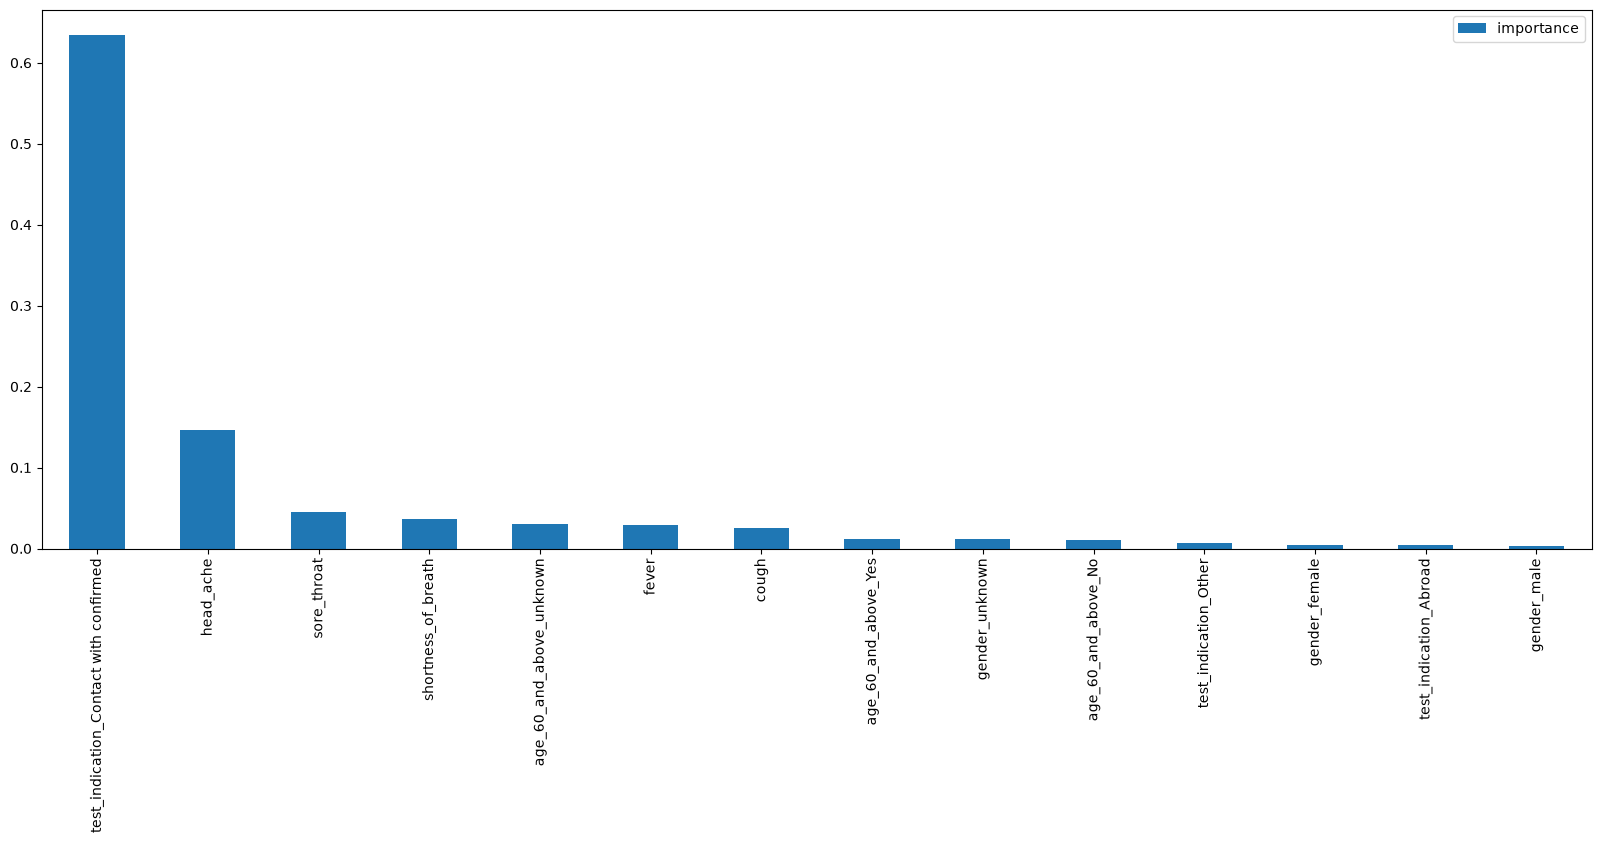

In [73]:
print(classification_report(y_test, dtc_y_pred))
print('='*53)


importances_df = pd.DataFrame(
    dtc_model.feature_importances_,
    columns=["importance"],
    index=X_train.columns
)
print(importances_df.sort_values("importance", ascending=False))

importances_df.sort_values("importance", ascending=False).plot(kind="bar", figsize=(20,7))
plt.show()

In [74]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_samples=0.9,   
    random_state=42)

rf.fit(X_train, y_train)

rf_y_pred = rf.predict(X_test)




              precision    recall  f1-score   support

       False       0.98      0.99      0.98     39002
        True       0.80      0.58      0.67      2204

    accuracy                           0.97     41206
   macro avg       0.89      0.79      0.83     41206
weighted avg       0.97      0.97      0.97     41206

                                        importance
test_indication_Contact with confirmed    0.362738
head_ache                                 0.135650
test_indication_Other                     0.102937
test_indication_Abroad                    0.095471
sore_throat                               0.072360
fever                                     0.068118
shortness_of_breath                       0.053164
cough                                     0.040245
age_60_and_above_unknown                  0.022040
gender_unknown                            0.013411
age_60_and_above_No                       0.011517
age_60_and_above_Yes                      0.010241
gender_mal

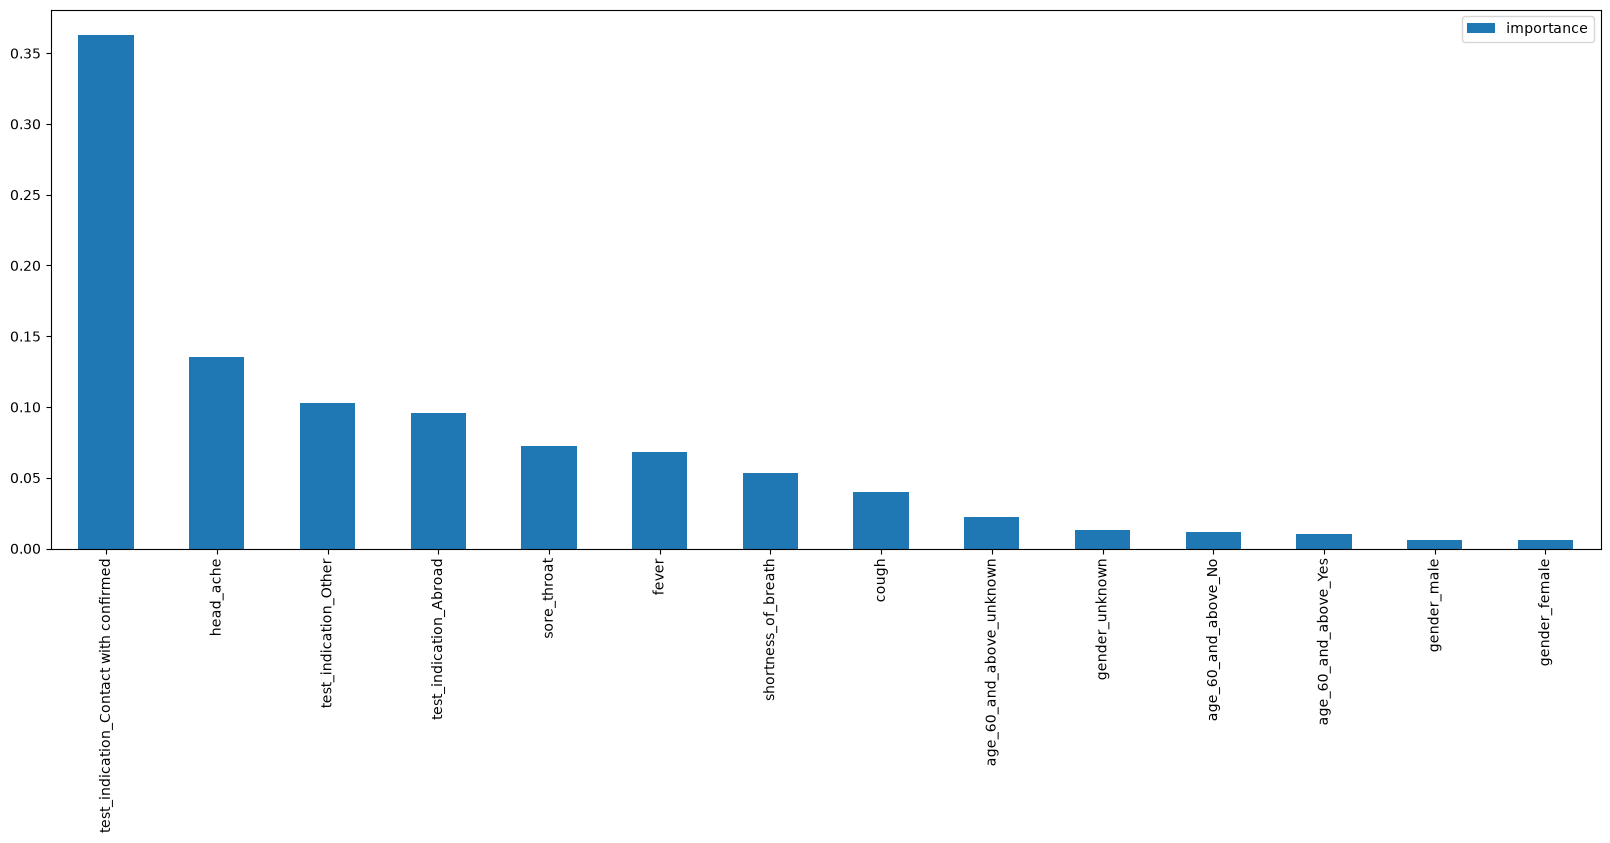

In [75]:
print(classification_report(y_test, rf_y_pred))
print('='*53)


importances_df = pd.DataFrame(
    rf.feature_importances_,
    columns=["importance"],
    index=X_train.columns
)
print(importances_df.sort_values("importance", ascending=False))

importances_df.sort_values("importance", ascending=False).plot(kind="bar", figsize=(20,7))
plt.show()

'gini'

In [ ]:
from sklearn.model_selection import GridSearchCV

params = dict(
    n_estimators=[100, 200],
    max_depth=[None], #, 1, 2],
    min_samples_split=[2, 3, 4],
    min_samples_leaf=[1, 2],
    max_samples=[0.75, 0.25, 0.9],
    
)



# rf = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=None,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     max_features="sqrt",
#     max_samples=0.9,   
#     random_state=42)

rf = RandomForestClassifier(random_state=5, n_jobs=-1)

gcv = GridSearchCV(estimator=rf, param_grid=params, n_jobs=-1, verbose=2)

gcv.fit(X_train, y_train)